### Data Extraction from PDF

##### Installing the required libraries:

In [1]:
%pip install pymupdf4llm Levenshtein pandas matplotlib seaborn scikit-learn pytesseract pillow

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Standard imports used throughout the project
import os, sys, csv, io
import time, re
import json
import warnings
import pandas as pd
import seaborn as sns
from datetime import datetime
from pathlib import Path
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings('ignore')

In [3]:
# Load API keys from .env
load_dotenv()  # reads .env in the project root

# Project root (works whether you open the notebook from the repo root or not)
ROOT = Path().resolve()
if not (ROOT / 'adapters').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

CORPUS_DIR      = ROOT / 'corpus'
GROUND_TRUTH_DIR = ROOT / 'ground_truth'
OUTPUT_DIR      = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'Root: {ROOT}')
print(f'PDFs found: {list(CORPUS_DIR.glob("*.pdf"))}')

Root: /workspaces/PDF_Data_Extraction
PDFs found: [PosixPath('/workspaces/PDF_Data_Extraction/corpus/2_perfect-pitch-deck.pdf'), PosixPath('/workspaces/PDF_Data_Extraction/corpus/5_ibm-annual-report-2025.pdf'), PosixPath('/workspaces/PDF_Data_Extraction/corpus/3_NVCA-Model-Voting-Agreement.pdf'), PosixPath('/workspaces/PDF_Data_Extraction/corpus/4_SA-war-scanned.pdf'), PosixPath('/workspaces/PDF_Data_Extraction/corpus/1_Rapport-financier-semestriel-AFD-2025.pdf')]


In [4]:
# Corpus overview: page count, file size, rough text vs image ratio
import fitz  # PyMuPDF

pdf_files = sorted(CORPUS_DIR.glob('*.pdf'))

if not pdf_files:
    print('No PDFs found in corpus/. Add your 5 PDFs first.')
else:
    print(f'{'PDF':<35} {'Pages':>6} {'Size MB':>8} {'Text chars':>12} {'Images':>8} {'Type guess':>12}')
    print('-' * 85)
    
    for pdf_path in pdf_files:
        doc = fitz.open(str(pdf_path))
        n_pages = doc.page_count
        size_mb = pdf_path.stat().st_size / 1e6
        total_chars, total_images = 0, 0
        for page in doc:
            total_chars  += len(page.get_text())
            total_images += len(page.get_images())
        avg_chars = total_chars / n_pages if n_pages else 0
        
        if avg_chars < 1000 and total_images > 5:
            pdf_type = 'Image-heavy'
        elif avg_chars > 5000:
            pdf_type = 'Text-heavy'
        else:
            pdf_type = 'Mixed'
        print(f'{pdf_path.name:<35} {n_pages:>6} {size_mb:>8.1f} {total_chars:>12,} {total_images:>8} {pdf_type:>12}')
        doc.close()

PDF                                  Pages  Size MB   Text chars   Images   Type guess
-------------------------------------------------------------------------------------
1_Rapport-financier-semestriel-AFD-2025.pdf     53      0.7      150,986        2        Mixed
2_perfect-pitch-deck.pdf                16      3.8        1,000       15  Image-heavy
3_NVCA-Model-Voting-Agreement.pdf       23      0.3       83,336        0        Mixed
4_SA-war-scanned.pdf                    15      0.6       18,285       30        Mixed
5_ibm-annual-report-2025.pdf           124      3.6      437,187        3        Mixed


##### Ground Truth:

In [30]:
# Generate a starting-point ground truth for one page 
GT_PDF  = pdf_files[0]   
GT_PAGE = 2           

doc  = fitz.open(str(GT_PDF))
page = doc[GT_PAGE - 1]

# extract text blocks from the page
blocks = page.get_text('blocks')

# Sort by vertical position then horizontal 
blocks_sorted = sorted(blocks, key=lambda b: (round(b[1]/20)*20, b[0]))

text_parts = []
for block in blocks_sorted:
    text = block[4].strip()

    if text:
        text_parts.append(text)

draft_text    = '\n\n'.join(b[4].strip() for b in blocks_sorted if b[4].strip())

doc.close()

In [31]:
# Print it for review
print(f'=== DRAFT ground truth: {GT_PDF.name}, page {GT_PAGE} ===')
print(draft_text[:5000])  # first 5000 chars
if len(draft_text) > 5000:
    print(f'... [{len(draft_text) - 5000} more chars — open the file to see all]')

# Auto-save (then manually edit the file) 
gt_dir = GROUND_TRUTH_DIR / GT_PDF.stem
gt_dir.mkdir(parents=True, exist_ok=True)
save_path = gt_dir / f'page_{GT_PAGE}.md'
save_path.write_text(draft_text, encoding='utf-8')
print(f'\nSaved to {save_path}')

=== DRAFT ground truth: 1_Rapport-financier-semestriel-AFD-2025.pdf, page 2 ===
AFD – 2025 half-year financial report 
2

Contents

A. Management report ............................................................................................................................ 4

1. AFD Group activities ....................................................................................................................... 4

2. Recent changes and outlook .......................................................................................................... 6 
2.1. Crises in several countries ................................................................................................... 6 
2.2. Refinancing and liquidity ...................................................................................................10 
2.3. Financial results .................................................................................................................11 
2.4. Capital adequacy 

In [11]:
# Extracting text from table
GT_PDF     = pdf_files[0]
TABLE_PAGE = 15

# Open PDF
with fitz.open(str(GT_PDF)) as doc:

    # PyMuPDF uses 0-based indexing
    page = doc[TABLE_PAGE - 1]

    # Print all text blocks with coordinates
    print(f'Text blocks on page {TABLE_PAGE}:\n')

    blocks = sorted(
        page.get_text("blocks"),
        key=lambda b: (b[1], b[0])   # sort top-to-bottom, left-to-right
    )

    for block in blocks:
        # Unpack block tuple
        x0, y0, x1, y1, text, block_no, block_type = block
        text = text.strip()

        if text:
            print(f'y={y0:6.0f}  x={x0:6.0f}  "{text[:80]}"')


# Manually reconstructed table from the PDF
correct_table = [
    # Header
    [
        'In thousands of euros',
        'Notes',
        '30 Jun 25',
        '31 Dec 24',
        'Change'
    ],

    # Rows
    ['Cash, due from central banks',
     ' ',
     '1,529,779',
     '863,504',
     '666,274'],

    ['Financial assets at fair value through profit or loss',
     '1',
     '3,868,930',
     '4,739,783',
     '(870,853)'],

    ['Hedging derivatives',
     '2',
     '2,586,028',
     '3,341,422',
     '(755,394)'],

    ['Financial assets at fair value through other comprehensive income',
     '3',
     '3,434,606',
     '2,273,869',
     '1,160,737'],

    ['Debt securities at amortised cost',
     '5',
     '4,031,971',
     '3,148,432',
     '883,539'],

    ['Financial assets at amortised cost',
     ' ',
     '53,009,695',
     '53,772,227',
     '(762,531)'],

    ['Loans and receivables due from credit institutions and equivalent at amortised cost',
     '5',
     '12,637,006',
     '13,303,340',
     '(666,334)'],

    ['On-demand',
     ' ',
     '932,054',
     '1,213,880',
     '(281,826)'],

    ['At maturity',
     ' ',
     '11,704,952',
     '12,089,460',
     '(384,508)'],

    ['Loans and receivables due from customers at amortised cost',
     '5',
     '40,372,689',
     '40,468,886',
     '(96,198)'],

    ['Other loans to customers',
     ' ',
     '40,372,689',
     '40,468,886',
     '(96,198)'],

    ['Of which calibration of the reserve account',
     ' ',
     '(1,047,780)',
     '(930,187)',
     '(117,592)'],

    ['Revaluation differences on interest rate-hedged portfolio',
     ' ',
     '14,045',
     '45,209',
     '(31,164)'],

    ['Current tax assets',
     ' ',
     '8,398',
     '5,966',
     '2,432'],

    ['Deferred tax assets',
     ' ',
     '27,419',
     '27,513',
     '(93)'],

    ['Accruals and other miscellaneous assets',
     '7',
     '3,466,979',
     '2,907,962',
     '559,017'],

    ['Accruals',
     ' ',
     '96,148',
     '53,516',
     '42,632'],

    ['Other assets',
     ' ',
     '3,370,831',
     '2,854,445',
     '516,386'],

    ['Equity stakes in companies accounted for by the equity method',
     '20',
     '158,014',
     '160,320',
     '(2,305)'],

    ['Fixed assets property, plant and equipment',
     '8',
     '902,952',
     '858,161',
     '44,791'],

    ['Intangible assets',
     '8',
     '190,124',
     '182,597',
     '7,527'],

    ['TOTAL ASSETS',
     ' ',
     '73,228,942',
     '72,326,964',
     '901,978']
]

correct_table1 = [

    # Header
    [
        'In thousands of euros',
        'Notes',
        '30 Jun 25',
        '31 Dec 24',
        'Change'
    ],

    # Rows
    ['Financial liabilities at fair value through profit or loss',
     '1',
     '95,270',
     '481,623',
     '(386,353)'],

    ['Hedging derivatives',
     '2',
     '4,159,400',
     '3,662,740',
     '496,660'],

    ['Financial liabilities at amortised cost',
     ' ',
     '54,396,791',
     '53,477,032',
     '919,759'],

    ['Debt securities in issue at amortised cost',
     '9',
     '54,362,989',
     '53,465,351',
     '897,639'],

    ['Interbank market securities',
     ' ',
     '2,012,968',
     '809,211',
     '1,203,757'],

    ['Bonds',
     ' ',
     '52,350,022',
     '52,656,140',
     '(306,118)'],

    ['Debts to credit institutions and equivalent at amortised cost',
     '9',
     '32,210',
     '9,556',
     '22,654'],

    ['On-demand',
     ' ',
     '21,648',
     '9,016',
     '12,633'],

    ['At maturity',
     ' ',
     '10,561',
     '540',
     '10,021'],

    ['Debts to customers at amortised cost',
     '9',
     '1,592',
     '2,125',
     '(533)'],

    ['Current tax liabilities',
     ' ',
     '7,470',
     '14,441',
     '(6,971)'],

    ['Deferred tax liabilities',
     ' ',
     '10,855',
     '13,872',
     '(3,017)'],

    ['Accruals and other miscellaneous liabilities',
     '7',
     '3,044,424',
     '3,330,294',
     '(285,870)'],

    ['Allocated public funds',
     ' ',
     '94,813',
     '87,110',
     '7,704'],

    ['Other liabilities',
     ' ',
     '2,949,610',
     '3,243,184',
     '(293,574)'],

    ['Provisions',
     '10',
     '803,953',
     '882,354',
     '(78,401)'],

    ['Of which calibration of the reserve account',
     ' ',
     '333,431',
     '285,324',
     '48,107'],

    ['Subordinated debt',
     '11',
     '987,897',
     '842,617',
     '145,280'],

    ['TOTAL DEBTS',
     ' ',
     '63,506,058',
     '62,704,972',
     '801,085'],

    ['Equity Group share',
     '(Tab 1)',
     '9,531,780',
     '9,422,346',
     '109,433'],

    ['Provisions and related retained earnings',
     ' ',
     '5,177,999',
     '5,177,999',
     '-'],

    ['Consolidated retained earnings and other',
     ' ',
     '4,068,114',
     '3,786,818',
     '281,296'],

    ['Gains and losses recognised in other comprehensive income',
     ' ',
     '131,493',
     '113,918',
     '17,575'],

    ['Earnings for the period',
     ' ',
     '154,174',
     '343,612',
     '(189,438)'],

    ['Non-controlling interests',
     '(Tab 1)',
     '191,105',
     '199,646',
     '(8,541)'],

    ['Total equity',
     ' ',
     '9,722,885',
     '9,621,992',
     '100,893'],

    ['TOTAL LIABILITIES',
     ' ',
     '73,228,942',
     '72,326,964',
     '901,978']
]

# Create output directory
gt_dir = GROUND_TRUTH_DIR / GT_PDF.stem
gt_dir.mkdir(parents=True, exist_ok=True)

# Save CSV
csv_path = gt_dir / 'page_15.csv'

with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerows(correct_table)
    writer.writerows(correct_table1)

print(f'\nSaved ground truth table to:\n{csv_path}')

Text blocks on page 15:

y=    23  x=    57  "AFD – 2025 half-year financial report 
15"
y=    61  x=    71  "Balance sheet at 30 June 2025"
y=    96  x=    73  "Assets"
y=   113  x=    73  "In thousands of euros
Notes
30 Jun 25
31 Dec 24
Change"
y=   127  x=    73  "Cash, due from central banks
1,529,779
863,504
666,274"
y=   139  x=    73  "Financial assets at fair value through profit or loss
1
3,868,930
4,739,783
(870"
y=   151  x=    73  "Hedging derivatives
2
2,586,028
3,341,422
(755,394)"
y=   163  x=    73  "Financial assets at fair value through other comprehensive income
3
3,434,606
2,"
y=   175  x=    73  "Debt securities at amortised cost
5
4,031,971
3,148,432
883,539"
y=   187  x=    73  "Financial assets at amortised cost
53,009,695
53,772,227
(762,531)"
y=   199  x=    73  "Loans and receivables due from credit institutions and equivalent at 
amortised "
y=   222  x=    80  "On-demand
932,054
1,213,880
(281,826)"
y=   234  x=    80  "At maturity
11,704,952
12,089,460
(38

##### Ground Truth for presentations & images

In [35]:
import pytesseract
from pytesseract import Output
from PIL import Image

GT_PDF  = pdf_files[5]
GT_PAGE = 11

doc  = fitz.open(str(GT_PDF))
page = doc[GT_PAGE - 1]

# Convert a page to image
pix = page.get_pixmap(dpi=300)
img = Image.open(io.BytesIO(pix.tobytes("png")))

In [36]:
# OCR extraction
ocr_data = pytesseract.image_to_data( img, output_type=pytesseract.Output.DICT)
doc.close()

In [37]:
lines = {}

for i in range(len(ocr_data["text"])):
    text = ocr_data["text"][i].strip()

    if not text:
        continue

    x = ocr_data["left"][i]
    y = ocr_data["top"][i]

    # group words into same line
    y_key = round(y / 15) * 15

    lines.setdefault(y_key, []).append((x, text))

# build pseudo-blocks
blocks = []

for y_key in sorted(lines.keys()):
    words = sorted(lines[y_key], key=lambda w: w[0])  # left → right

    line_text = " ".join(w[1] for w in words)

    x0 = words[0][0]

    blocks.append((x0, y_key, x0, y_key, line_text))


blocks_sorted = sorted(
    blocks,
    key=lambda b: (round(b[1] / 20) * 20, b[0])
)

draft_text = "\n\n".join(
    b[4] for b in blocks_sorted if b[4].strip()
)

print(draft_text)

INDIVIDUAL SHAREHOLDERS

SHAREHOLDERS’

THE SCC: A COMMUNICATION

COMMITTEE TO TALK WITH THE GROUP

THEIR VOICES, OUR COMMITMENTS

ur individual shareholders are essential partners in our growth. Ambitious industrial

projects, environmental impact, intergenerational transmission: their voices

reflect their expectations, their convictions, and their attachment to Air Liquide.

The privileged relationship that unites us fuels our ambition to keep building the

Group's future together.

Air Liquide is positioned

on future-defining technologies.

I'm convinced

| became an Air Liquide shareholder thanks to my father. He'd

I'm investing ina to get me a was

been trying started for long time, but | a little

intimidated by the stock market. When daughter born,

my was

solid company.

he made it concrete: he of to buy

very gave me a sum money

Air Liquide shares for her. So my daughter became a shareholder

Air Liquide was my very first

at just six months old, and | became one as well 

In [38]:
# Auto-save (then manually edit the file) 
gt_dir = GROUND_TRUTH_DIR / GT_PDF.stem
gt_dir.mkdir(parents=True, exist_ok=True)
save_path = gt_dir / f'page_{GT_PAGE}.md'
save_path.write_text(draft_text, encoding='utf-8')
print(f'\nSaved to {save_path}')


Saved to /workspaces/PDF_Data_Extraction/ground_truth/6_2025-integrated-annual-report/page_11.md


Ground Table for charts:

In [29]:
from collections import defaultdict

GT_PDF  = pdf_files[5]
GT_PAGE = 10

doc  = fitz.open(str(GT_PDF))
page = doc[GT_PAGE - 1]

# Extract text blocks 
raw_blocks = page.get_text("blocks")   # (x0, y0, x1, y1, text, block_no, block_type)
page_width = page.rect.width

doc.close()

In [30]:
# Column-aware sorting helper

N_COLS = 2   # for two-column pages

def col_key(block, page_width, n_cols=N_COLS):
    col = int(block[0] / (page_width / n_cols))
    return (col, round(block[1] / 10) * 10, block[0])

# Deduplicate & sort blocks
seen   = set()
blocks = []

for block in sorted(raw_blocks, key=lambda b: col_key(b, page_width)):
    text = block[4].strip()
    norm = re.sub(r"\s+", " ", text).lower()
    if text and norm not in seen:
        seen.add(norm)
        blocks.append(block)


# Sort blocks (column → top → bottom)
blocks_sorted = sorted(
    blocks,
    key=lambda b: col_key(b, page_width)
)

# Build draft text
text_parts = []

for block in blocks_sorted:
    text = block[4].strip()
    if text:
        text_parts.append(text)

draft_text = "\n\n".join(text_parts)


In [31]:
# Print for review
print(f'=== DRAFT ground truth: {GT_PDF.name}, page {GT_PAGE} ===')
print(draft_text[:3000])

if len(draft_text) > 3000:
    print(f'... [{len(draft_text) - 3000} more chars — open file to see all]')

# Auto-save ground truth
gt_dir = GROUND_TRUTH_DIR / GT_PDF.stem
gt_dir.mkdir(parents=True, exist_ok=True)
save_path = gt_dir / f'page_{GT_PAGE}.md'
save_path.write_text(
    draft_text,
    encoding='utf-8'
)

print(f'\nSaved to:\n{save_path}')

=== DRAFT ground truth: 6_2025-integrated-annual-report.pdf, page 10 ===
OUR SHAREHOLDERS

PARTNERS IN PERFORMANCE

At Air Liquide, the structure of our shareholder 
base is a major asset. It is built on a unique 
complementarity between our institutional 
investors, who bring ǖnancial strength, international diversity 
and high standards in governance and sustainability, and our 
individual shareholders, the long-standing pillars of our 
shareholder stability.

Together, they form a distinctive foundation built on strong values of 
transparency and dialogue, which are essential to understanding our 
performance and strategy. This relationship of mutual trust, built over time, 
facilitates investment decisions and drives the major strategic choices that 
support our growth, such as the recent acquisition of DIG Airgas in South Korea. 
It also enables us to create value in a consistent, responsible and sustainable 
way for all.

Aude Rodriguez,

VP HEAD OF INVESTOR RELATIONS AT AIR LIQU

### Score Helpers (CER, TEDS)

In [5]:
import unicodedata

# ── Corrected CER helper ─────────────────────────────────────────────────────
from jiwer import cer as _jiwer_cer

def normalize(text: str) -> str:
    """NFC + collapse whitespace + lowercase."""
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip().lower()

def extract_page_text(full_text: str, page_num: int,
                      separator: str = '\f') -> str:
    """
    Pull one page out of the full extracted text.
    Tools that use \\f as page separator (pymupdf4llm, our adapters) work directly.
    For tools that don't paginate: fall back to a keyword search window.
    """
    pages = full_text.split(separator)
    if len(pages) > 1:
        idx = page_num - 1
        return pages[idx] if idx < len(pages) else ''
    # Fallback: no page breaks — return whole text (will give higher CER, flag it)
    return full_text

def compute_cer(hypothesis_page: str, reference_page: str) -> float:
    """
    CER between ONE extracted page and ONE ground-truth page.
    Always pass a single page on each side — never the full document.
    Returns 0.0 (perfect) … 1.0+ (very wrong).
    """
    ref = normalize(reference_page)
    hyp = normalize(hypothesis_page)
    if not ref:
        return 0.0
    # jiwer signature: cer(reference, hypothesis)
    return round(_jiwer_cer(ref, hyp), 4)

def cer_to_score5(cer_val: float) -> float:
    if cer_val <= 0.05:  return 5.0   # < 5% error  → excellent
    if cer_val <= 0.10:  return 4.0   # 5–10%       → good
    if cer_val <= 0.20:  return 3.0   # 10–20%      → acceptable
    if cer_val <= 0.40:  return 2.0   # 20–40%      → poor
    return 1.0                        # > 40%       → failing

print("✅ CER helpers ready")

✅ CER helpers ready


In [6]:
# ── Corrected TEDS helper ────────────────────────────────────────────────────
import Levenshtein

def _table_to_tree(table: list) -> str:
    rows = []
    for row in table:
        cells = "".join(f"(td {normalize(str(c))})" for c in row)
        rows.append(f"(tr {cells})")
    return f"(table {''.join(rows)})"

def compute_teds(pred: list, gt: list) -> float:
    if not gt:   return 1.0
    if not pred: return 0.0
    pred_str = _table_to_tree(pred)
    gt_str   = _table_to_tree(gt)
    dist     = Levenshtein.distance(pred_str, gt_str)
    max_len  = max(len(pred_str), len(gt_str))
    return round(1.0 - dist / max_len, 4) if max_len else 1.0

def find_table_by_page(tables: list, page_num: int) -> list:
    """
    Find the table from a specific page number.
    Works with the {'page': N, 'data': [...]} format from pymupdf_results.
    """
    for tbl in tables:
        if tbl.get('page') == page_num:
            return tbl.get('data', [])
    # No exact match — return the closest
    if tables:
        print(f"  ⚠ No table on page {page_num}. Using table from page "
              f"{tables[0].get('page','?')} instead.")
        return tables[0].get('data', [])
    return []

print("✅ TEDS helpers ready")

✅ TEDS helpers ready


In [7]:
# ── CER helper ────────────────────────────────────────────────────
from jiwer import cer as _jiwer_cer

def compute_cer(hypothesis: str, reference: str) -> float:
    """
    Character Error Rate — lower is better (0.0 = perfect).
    Normalises whitespace before comparison.
    """
    ref  = re.sub(r'\s+', ' ', reference.strip())
    hyp  = re.sub(r'\s+', ' ', hypothesis.strip())
    if not ref:
        return 0.0
    return round(_jiwer_cer(ref, hyp), 4)

def cer_to_score5(cer: float) -> float:
    """Map CER (0–1+) to a 1–5 quality score."""
    if cer <= 0.05:  return 5.0
    if cer <= 0.10:  return 4.0
    if cer <= 0.20:  return 3.0
    if cer <= 0.40:  return 2.0
    return 1.0

print("✅ CER helper ready")

✅ CER helper ready


In [8]:
# TEDS helper

import Levenshtein

def _table_to_tree(table: list[list[str]]) -> str:
    """Linearise a 2-D table as a bracketed string (tree proxy)."""
    rows = []
    for row in table:
        cells = "".join(f"(td {str(c).strip()})" for c in row)
        rows.append(f"(tr {cells})")
    return f"(table {''.join(rows)})"

def compute_teds(pred: list[list[str]], gt: list[list[str]]) -> float:
    """
    TEDS-like score 0.0–1.0 (1.0 = perfect structural + content match).
    Uses normalised Levenshtein on linearised table strings.
    """
    if not gt:   return 1.0
    if not pred: return 0.0
    pred_str = _table_to_tree(pred)
    gt_str   = _table_to_tree(gt)
    dist     = Levenshtein.distance(pred_str, gt_str)
    max_len  = max(len(pred_str), len(gt_str))
    return round(1.0 - dist / max_len, 4) if max_len else 1.0

def teds_to_score5(teds: float) -> float:
    """Map TEDS (0–1) to a 1–5 quality score."""
    if teds >= 0.95: return 5.0
    if teds >= 0.85: return 4.0
    if teds >= 0.70: return 3.0
    if teds >= 0.50: return 2.0
    return 1.0

print("✅ TEDS helper ready")


✅ TEDS helper ready


In [9]:
# Ground truth loader 
def load_gt_text(pdf_stem: str, page: int) -> str:
    """Load a manually-edited .md ground-truth file."""
    p = GROUND_TRUTH_DIR / pdf_stem / f'page_{page}.md'
    return p.read_text(encoding='utf-8') if p.exists() else ''

def load_gt_table(pdf_stem: str, page: int) -> list[list[str]]:
    """Load a ground-truth CSV table. Returns [] if not found."""
    p = GROUND_TRUTH_DIR / pdf_stem / f'page_{page}.csv'
    if not p.exists():
        return []
    with open(p, newline='', encoding='utf-8') as f:
        return list(csv.reader(f))

# ── Results accumulator (populated after every tool) ──────────────
RESULTS: list[dict] = []

def record(tool, pdf, cer_val, teds_val, elapsed, pages, cost=0.0, notes=''):
    """Append one row to the master results list."""
    RESULTS.append({
        'tool'     : tool,
        'pdf'      : pdf,
        'CER'      : cer_val,
        'CER_score': cer_to_score5(cer_val),
        'TEDS'     : teds_val,
        'TEDS_score': teds_to_score5(teds_val),
        'elapsed_s': round(elapsed, 2),
        'pages'    : pages,
        'cost_usd' : cost,
        'notes'    : notes,
    })
    print(f"  CER={cer_val:.4f} (score {cer_to_score5(cer_val)}/5)  "
          f"TEDS={teds_val:.4f} (score {teds_to_score5(teds_val)}/5)  "
          f"{elapsed:.1f}s  {pages}pp")

print("✅ Ground-truth loader & results accumulator ready")
print("   RESULTS list will be populated after each tool section.")


✅ Ground-truth loader & results accumulator ready
   RESULTS list will be populated after each tool section.


## PDF Extraction

**Goal:** Extract text, tables, images, and metadata from PDF files.

1. PyMuPDF4llm

In [8]:
import fitz
import pymupdf4llm

TOOL = 'pymupdf4llm'
tool_out_dir = OUTPUT_DIR / TOOL
tool_out_dir.mkdir(exist_ok=True)

pymupdf_results = {}   # pdf_stem → dict

for pdf_path in pdf_files:
    stem = pdf_path.stem
    t0   = time.perf_counter()
    doc  = fitz.open(str(pdf_path))

    # ── Text (reading-order markdown) ────────────────────────────────
    md_text = pymupdf4llm.to_markdown(str(pdf_path))

    # ── Plain text page-by-page ───────────────────────────────────────
    plain_pages, all_tables = [], []

    for page in doc:
        plain_pages.append(page.get_text('text'))

        # ── Tables ───────────────────────────────────────────────────
        for tbl in page.find_tables():
            extracted = tbl.extract()   # list[list[str|None]]
            clean = [[c if c else '' for c in row] for row in extracted]
            all_tables.append({'page': page.number + 1, 'data': clean})

    # ── Images ───────────────────────────────────────────────────────
    img_dir  = tool_out_dir / stem / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)
    img_paths = []

    for pg_idx, page in enumerate(doc):
        for img_idx, img_info in enumerate(page.get_images(full=True)):
            xref   = img_info[0]
            base   = doc.extract_image(xref)
            suffix = base['ext']
            img_bytes = base['image']
            out_path  = img_dir / f'pg{pg_idx+1}_img{img_idx+1}.{suffix}'
            out_path.write_bytes(img_bytes)
            img_paths.append(str(out_path))

    n_pages = doc.page_count
    doc.close()
    elapsed = time.perf_counter() - t0

    pymupdf_results[stem] = {
        'markdown' : md_text,
        'plain'    : '\n'.join(plain_pages),
        'tables'   : all_tables,
        'images'   : img_paths,
        'pages'    : n_pages,
        'elapsed'  : elapsed,
    }

    # Save outputs
    (tool_out_dir / f'{stem}_markdown.md').write_text(md_text, encoding='utf-8')
    with open(tool_out_dir / f'{stem}_tables.json', 'w', encoding='utf-8') as f:
        json.dump(all_tables, f, ensure_ascii=False, indent=2)

    print(f'[{TOOL}] {stem:<30} {n_pages:>4}pp  {len(all_tables):>3} tables  '
          f'{len(img_paths):>3} images  {elapsed:.1f}s')

2026-05-29 07:23:24.700530773 [W:onnxruntime:Default, device_discovery.cc:133 GetPciBusId] Skipping pci_bus_id for PCI path at "/sys/devices/LNXSYSTM:00/LNXSYBUS:00/PNP0A03:00/device:07/VMBUS:01/5620e0c7-8062-4dce-aeb7-520c7ef76171" because filename "5620e0c7-8062-4dce-aeb7-520c7ef76171" did not match expected pattern of [0-9a-f]+:[0-9a-f]+:[0-9a-f]+[.][0-9a-f]+


=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=0/1.
OCR on page.number=25/26.

[pymupdf4llm] 1_Rapport-financier-semestriel-AFD-2025   53pp   56 tables    2 images  50.0s
=== Document parser messages ===
                                                                                      Using Tesseract for OCR processing.
OCR on page.number=0/1.
OCR on page.number=1/2.
OCR on page.number=2/3.
OCR on page.number=3/4.
OCR on page.number=4/5.
OCR on page.number=5/6.
OCR on page.number=6/7.
OCR on page.number=7/8.
OCR on page.number=8/9.
OCR on page.number=9/10.
OCR on page.number=10/11.
OCR on page.number=11/12.
OCR on page.number=12/13.
OCR on page.number=13/14.
OCR on page.number=14/15.

[pymupdf4llm] 2_perfect-pitch-deck             16pp    0 tables   15 images  22.0s
=== Document parser messages ===
                                                                                                                                                 

In [10]:
# ── Preview: first 800 chars of markdown for the first PDF ───────
stem   = pdf_files[0].stem
sample = pymupdf_results[stem]
print(f'=== {TOOL} | {stem} — markdown preview ===')
print(sample['markdown'][:800])

=== pymupdf4llm | 1_Rapport-financier-semestriel-AFD-2025 — markdown preview ===
## **Half-year financial report** 

**30 June 2025** 

AFD – 2025 half-year financial report 

2 

**Contents** A. Management report ............................................................................................................................ 4 1. AFD Group activities ....................................................................................................................... 4 2. Recent changes and outlook .......................................................................................................... 6 2.1. Crises in several countries ................................................................................................... 6 2.2. Refinancing and liquidity .........................................................................................


In [11]:
# ── Preview: tables found in first PDF ───────────────────────────
stem   = pdf_files[0].stem
tables = pymupdf_results[stem]['tables']
print(f'Tables found: {len(tables)}')
for i, tbl in enumerate(tables[:3]):
    print(f'\n-- Table {i+1} (page {tbl["page"]}) --')
    df = pd.DataFrame(tbl['data'])
    print(df.to_string(index=False, header=False))

Tables found: 56

-- Table 1 (page 2) --
                                                                                                                                                    Contents
        A Managementreport 4\n. ............................................................................................................................
           1 AFDGroupactivities 4\n. .......................................................................................................................
                   2 Recentchangesandoutlook 6\n. ..........................................................................................................
                      21 Crisesinseveralcountries 6\n. . ...................................................................................................
                      22 Refinancingandliquidity 10\n. . ...................................................................................................
               23

##### Tool 1 - Pymupdf4llm evaluation — CER + TEDS

In [19]:
# ── Corrected evaluation block (replace your existing CER/TEDS eval cells) ──
GT_PAGE_NUM   = 2    # the page you ground-truthed
GT_TABLE_PAGE = 15   # the page that has the balance sheet table

for stem, res in pymupdf_results.items():
    gt_text = load_gt_text(stem, GT_PAGE_NUM)
    if not gt_text:
        print(f"  {stem}: no GT text"); continue

    # Extract ONLY the ground-truthed page from the tool output
    pred_page = extract_page_text(res['plain'], GT_PAGE_NUM, separator='\f')
    if not pred_page.strip():
        # pymupdf plain text doesn't have \f — try the markdown output
        pred_page = extract_page_text(res['markdown'], GT_PAGE_NUM, separator='\f')

    cer_val = compute_cer(pred_page, gt_text)

    # TEDS: find the table that lives on page 15, not just tables[0]
    gt_table   = load_gt_table(stem, GT_TABLE_PAGE)
    pred_table = find_table_by_page(res['tables'], GT_TABLE_PAGE)
    teds_val   = compute_teds(pred_table, gt_table) if gt_table else 0.0

    print(f"[pymupdf4llm] {stem}")
    print(f"  CER  = {cer_val:.4f}  → {cer_to_score5(cer_val)}/5")
    print(f"  TEDS = {teds_val:.4f}  → {teds_to_score5(teds_val)}/5")

[pymupdf4llm] 1_Rapport-financier-semestriel-AFD-2025
  CER  = 35.1070  → 1.0/5
  TEDS = 0.2517  → 1.0/5
  2_perfect-pitch-deck: no GT text
[pymupdf4llm] 3_NVCA-Model-Voting-Agreement
  CER  = 24.7465  → 1.0/5
  TEDS = 0.0000  → 1.0/5
[pymupdf4llm] 4_SA-war-scanned
  CER  = 15.8215  → 1.0/5
  TEDS = 0.0000  → 1.0/5
  6_ibm-annual-report-2025: no GT text


In [22]:
# ── CER for each PDF (text ground truth on the annotated pages) ───
print(f'=== {TOOL} — CER evaluation ===')

for pdf_path in pdf_files:
    stem    = pdf_path.stem
    gt_text = load_gt_text(stem, 4)   # page 4 ground truth

    if not gt_text:
        print(f'  {stem}: no text ground truth yet — skipping')
        continue

    hyp_text = pymupdf_results[stem]['plain']
    cer_val  = compute_cer(hyp_text, gt_text)
    print(f'  {stem}: CER = {cer_val:.4f}  → score {cer_to_score5(cer_val)}/5')

=== pymupdf4llm — CER evaluation ===
  1_Rapport-financier-semestriel-AFD-2025: CER = 57.2034  → score 1.0/5
  2_perfect-pitch-deck: CER = 1.1332  → score 1.0/5
  3_NVCA-Model-Voting-Agreement: no text ground truth yet — skipping
  4_SA-war-scanned: CER = 11.9307  → score 1.0/5
  6_ibm-annual-report-2025: no text ground truth yet — skipping


In [23]:
# ── TEDS for each PDF (table ground truth page 15) ────────────────
print(f'=== {TOOL} — TEDS evaluation ===')

GT_TABLE_STEM = pdf_files[0].stem
GT_TABLE_PAGE = 15
gt_table      = load_gt_table(GT_TABLE_STEM, GT_TABLE_PAGE)

tables_this_pdf = pymupdf_results.get(GT_TABLE_STEM, {}).get('tables', [])

# Find table closest to ground-truth page
pred_table = []
for tbl in tables_this_pdf:
    if tbl['page'] == GT_TABLE_PAGE:
        pred_table = tbl['data']
        break
if not pred_table and tables_this_pdf:
    pred_table = tables_this_pdf[0]['data']   # fallback: first table

teds_val = compute_teds(pred_table, gt_table)
print(f'  {GT_TABLE_STEM} page {GT_TABLE_PAGE}: TEDS = {teds_val:.4f}  → score {teds_to_score5(teds_val)}/5')

# ── Record in master results ───────────────────────────────────────
res0     = pymupdf_results[GT_TABLE_STEM]
cer_val  = compute_cer(res0['plain'], load_gt_text(GT_TABLE_STEM, 2))
record(TOOL, GT_TABLE_STEM, cer_val, teds_val,
       res0['elapsed'], res0['pages'], cost=0.0,
       notes='Baseline native parser. No OCR — scanned PDFs will score poorly.')

=== pymupdf4llm — TEDS evaluation ===
  1_Rapport-financier-semestriel-AFD-2025 page 15: TEDS = 0.2517  → score 1.0/5
  CER=35.1070 (score 1.0/5)  TEDS=0.2517 (score 1.0/5)  50.0s  53pp


### 📝 PyMuPDF4LLM findings

| Dimension | Observation |
|-----------|-------------|
| Reading order | 3 |
| Heading detection | 3 |
| Table quality | 2 |
| OCR (scanned PDF) | |

## Tool 2 · Docling 
**Strengths:** Best-in-class table structure, heading hierarchy, multi-column layout.  
**Install:** `pip install docling`

In [8]:
%pip install docling --quiet

Note: you may need to restart the kernel to use updated packages.


In [10]:
from docling.document_converter import DocumentConverter
from docling.datamodel.pipeline_options import PdfPipelineOptions

pipeline_opts = PdfPipelineOptions()
pipeline_opts.do_ocr = False             # disable RapidOCR completely
pipeline_opts.do_table_structure = False # disable TableFormer

converter = DocumentConverter()

# Process ONE pdf at a time
TEST_PDF = pdf_files[0]
result   = converter.convert(str(TEST_PDF))
doc      = result.document
md_out   = doc.export_to_markdown()

print(f"Pages: {len(doc.pages)}, Tables: {len(doc.tables)}")
print(md_out[:1000])

2026-05-29 09:21:54.219675274 [W:onnxruntime:Default, device_discovery.cc:133 GetPciBusId] Skipping pci_bus_id for PCI path at "/sys/devices/LNXSYSTM:00/LNXSYBUS:00/PNP0A03:00/device:07/VMBUS:01/5620e0c7-8062-4dce-aeb7-520c7ef76171" because filename "5620e0c7-8062-4dce-aeb7-520c7ef76171" did not match expected pattern of [0-9a-f]+:[0-9a-f]+:[0-9a-f]+[.][0-9a-f]+
[INFO] 2026-05-29 09:21:55,582 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-29 09:21:55,616 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/python/3.12.1/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-05-29 09:21:55,617 [RapidOCR] main.py:57: Using /usr/local/python/3.12.1/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-05-29 09:21:55,755 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-29 09:21:55,764 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/python/3.12.1/lib/py

: 

In [11]:
# ── Save outputs ──────────────────────────────────────────────────────────────
stem    = TEST_PDF.stem
out_dir = OUTPUT_DIR / 'docling' / stem
out_dir.mkdir(parents=True, exist_ok=True)

# 1. Markdown text
(out_dir / 'text_markdown.md').write_text(md_out, encoding='utf-8')

9480

In [14]:
# 2. Tables — one CSV per table, filename includes page number
tables_dir = out_dir / 'tables'
tables_dir.mkdir(exist_ok=True)
for i, tbl_item in enumerate(doc.tables):
    try:
        df    = tbl_item.export_to_dataframe()
        provs = getattr(tbl_item, 'prov', [])
        pg_no = getattr(provs[0], 'page_no', 0) if provs else 0
        fname = tables_dir / f'table_{i+1:02d}_page{pg_no}.csv'
        df.to_csv(fname, index=False)
    except Exception as e:
        print(f'  [warn] Table {i+1} export failed: {e}')

In [ ]:
# 3. Images / figures (cropped from the PDF using fitz)
import fitz
from PIL import Image as PILImage
imgs_dir = out_dir / 'images'
imgs_dir.mkdir(exist_ok=True)
raw_doc = fitz.open(str(TEST_PDF))
for i, pic in enumerate(getattr(doc, 'pictures', [])):
    try:
        provs = getattr(pic, 'prov', [])
        pg_no = getattr(provs[0], 'page_no', 1) if provs else 1
        bbox  = provs[0].bbox if provs else None
        if bbox:
            pg   = raw_doc[pg_no - 1]
            rect = fitz.Rect(bbox.l, bbox.t, bbox.r, bbox.b)
            pix  = pg.get_pixmap(clip=rect, matrix=fitz.Matrix(2, 2))
            img  = PILImage.open(io.BytesIO(pix.tobytes('png')))
            if img.width > 50 and img.height > 50:
                img.save(imgs_dir / f'figure_{i+1:02d}_page{pg_no}.png')
    except Exception:
        pass
raw_doc.close()

In [13]:
from docling.document_converter import DocumentConverter
from docling.datamodel.pipeline_options import PdfPipelineOptions
import json, csv, io
from pathlib import Path
from PIL import Image as PILImage

pipeline_opts = PdfPipelineOptions()
pipeline_opts.do_ocr = False             # disable RapidOCR completely
pipeline_opts.do_table_structure = False # disable TableFormer

converter = DocumentConverter()

# Process ONE pdf at a time
TEST_PDF = pdf_files[1]
result   = converter.convert(str(TEST_PDF))
doc      = result.document
md_out   = doc.export_to_markdown()

print(f"Pages: {len(doc.pages)}, Tables: {len(doc.tables)}")
print(md_out[:1000])

# ── Save outputs ──────────────────────────────────────────────────────────────
stem    = TEST_PDF.stem
out_dir = OUTPUT_DIR / 'docling' / stem
out_dir.mkdir(parents=True, exist_ok=True)

# 1. Markdown text
(out_dir / 'text_markdown.md').write_text(md_out, encoding='utf-8')

# 2. Plain text (page-separated with \f so CER scoring works correctly)
page_texts = []
for page_item in doc.pages:
    pg_num = page_item.page_no
    parts  = [item.text for item in doc.texts
               if any(getattr(p, 'page_no', None) == pg_num
                      for p in getattr(item, 'prov', []))]
    page_texts.append('\n'.join(parts))
plain_text = '\f'.join(page_texts)
(out_dir / 'text_plain.md').write_text(plain_text, encoding='utf-8')

# 3. Tables — one CSV per table, filename includes page number
tables_dir = out_dir / 'tables'
tables_dir.mkdir(exist_ok=True)
for i, tbl_item in enumerate(doc.tables):
    try:
        df    = tbl_item.export_to_dataframe()
        provs = getattr(tbl_item, 'prov', [])
        pg_no = getattr(provs[0], 'page_no', 0) if provs else 0
        fname = tables_dir / f'table_{i+1:02d}_page{pg_no}.csv'
        df.to_csv(fname, index=False)
    except Exception as e:
        print(f'  [warn] Table {i+1} export failed: {e}')

# 4. Images / figures (cropped from the PDF using fitz)
import fitz
imgs_dir = out_dir / 'images'
imgs_dir.mkdir(exist_ok=True)
raw_doc = fitz.open(str(TEST_PDF))
for i, pic in enumerate(getattr(doc, 'pictures', [])):
    try:
        provs = getattr(pic, 'prov', [])
        pg_no = getattr(provs[0], 'page_no', 1) if provs else 1
        bbox  = provs[0].bbox if provs else None
        if bbox:
            pg   = raw_doc[pg_no - 1]
            rect = fitz.Rect(bbox.l, bbox.t, bbox.r, bbox.b)
            pix  = pg.get_pixmap(clip=rect, matrix=fitz.Matrix(2, 2))
            img  = PILImage.open(io.BytesIO(pix.tobytes('png')))
            if img.width > 50 and img.height > 50:
                img.save(imgs_dir / f'figure_{i+1:02d}_page{pg_no}.png')
    except Exception:
        pass
raw_doc.close()

# 5. Metadata JSON
n_imgs = len(list(imgs_dir.glob('*.png')))
meta   = {
    'tool'     : 'docling',
    'pdf'      : TEST_PDF.name,
    'pages'    : len(doc.pages),
    'tables'   : len(doc.tables),
    'images'   : n_imgs,
    'settings' : {'do_ocr': False, 'do_table_structure': False},
}
(out_dir / 'meta.json').write_text(
    json.dumps(meta, indent=2), encoding='utf-8')

print(f'\nSaved to: {out_dir}')
print(f'  text_markdown.md  — {len(md_out):,} chars')
print(f'  text_plain.md     — {len(plain_text):,} chars  ({len(page_texts)} pages)')
print(f'  tables/           — {len(doc.tables)} CSV files')
print(f'  images/           — {n_imgs} PNG files')
print(f'  meta.json')

[INFO] 2026-05-29 09:10:36,321 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-29 09:10:36,360 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/python/3.12.1/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-05-29 09:10:36,361 [RapidOCR] main.py:57: Using /usr/local/python/3.12.1/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-05-29 09:10:36,602 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-29 09:10:36,610 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/python/3.12.1/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-05-29 09:10:36,612 [RapidOCR] main.py:57: Using /usr/local/python/3.12.1/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-05-29 09:10:36,703 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-29 09:10:36,765 [Rapid

: 

In [ ]:
TOOL = 'docling'

GT_TEXT_PAGE  = 2
GT_TABLE_PDF  = pdf_files[0].stem
GT_TABLE_PAGE = 15

# Two pipeline configurations:
USE_TABLE_STRUCTURE = False   # to prevent kernel crashes

opts = PdfPipelineOptions()
opts.do_ocr             = False             # prevents RapidOCR OOM crash
opts.do_table_structure = USE_TABLE_STRUCTURE

SCANNED_STEMS = {'4_SA-war-scanned'}  # needs OCR — skip Docling or use fallback

for pdf_path in pdf_files:
    stem = pdf_path.stem
    print(f'\n[{TOOL}] Processing: {pdf_path.name}')

    if stem in SCANNED_STEMS:
        print('  Skipping scanned PDF (OCR disabled to prevent crash). '
              'Use PyMuPDF4LLM or Mistral OCR for this document.')
        continue

    # Fresh converter per PDF — releases memory after each document
    converter = DocumentConverter(
        format_options={InputFormat.PDF: PdfFormatOption(pipeline_options=opts)}
    )

    t0     = time.perf_counter()
    result = converter.convert(str(pdf_path))
    doc    = result.document

    # ── Text: export as plain text, insert \f between pages ──────────────────
    page_texts = []
    for page_item in doc.pages:
        # Collect text elements that belong to this page
        pg_num = page_item.page_no
        pg_text_parts = []
        for item in doc.texts:
            provs = getattr(item, 'prov', [])
            if any(getattr(p, 'page_no', None) == pg_num for p in provs):
                pg_text_parts.append(item.text)
        page_texts.append('\n'.join(pg_text_parts))
    full_text = '\f'.join(page_texts)
    # Fallback: if page_texts is all empty, use export_to_text
    if not full_text.strip():
        full_text = doc.export_to_text()

    md_text = doc.export_to_markdown()

    # ── Tables ────────────────────────────────────────────────────────────────
    all_tables = []
    for tbl_item in doc.tables:
        try:
            df   = tbl_item.export_to_dataframe()
            data = [list(df.columns)] + df.values.tolist()
            # Get page number from provenance
            provs = getattr(tbl_item, 'prov', [])
            pg_no = getattr(provs[0], 'page_no', 0) if provs else 0
            all_tables.append({'page': pg_no, 'data': [[str(c) for c in row] for row in data]})
        except Exception as e:
            print(f'  [warn] Table export failed: {e}')

    # ── Images/figures ────────────────────────────────────────────────────────
    pil_images = []
    raw_doc    = fitz.open(str(pdf_path))
    for pic in getattr(doc, 'pictures', []):
        try:
            provs  = getattr(pic, 'prov', [])
            pg_no  = getattr(provs[0], 'page_no', 1) if provs else 1
            bbox   = provs[0].bbox if provs else None
            if bbox:
                pg   = raw_doc[pg_no - 1]
                rect = fitz.Rect(bbox.l, bbox.t, bbox.r, bbox.b)
                pix  = pg.get_pixmap(clip=rect, matrix=fitz.Matrix(2, 2))
                img  = PILImage.open(io.BytesIO(pix.tobytes('png')))
                if img.width > 50 and img.height > 50:
                    pil_images.append(img)
        except Exception:
            pass
    raw_doc.close()

    n_pages = len(doc.pages)
    elapsed = time.perf_counter() - t0

    # ── Save ──────────────────────────────────────────────────────────────────
    save_outputs(TOOL, stem, full_text, all_tables,
                 {'tool': TOOL, 'pdf': pdf_path.name, 'pages': n_pages,
                  'tables': len(all_tables), 'images': len(pil_images),
                  'elapsed_s': round(elapsed, 2),
                  'settings': {'do_ocr': False, 'do_table_structure': USE_TABLE_STRUCTURE}},
                 pil_images)
    (OUTPUT_DIR / TOOL / stem / 'text_markdown.md').write_text(md_text, encoding='utf-8')

    # ── Evaluate ─────────────────────────────────────────────────────────────
    gt_text   = load_gt_text(stem, GT_TEXT_PAGE)
    pred_page = extract_page(full_text, GT_TEXT_PAGE)
    cer_val   = compute_cer(pred_page, gt_text) if gt_text else 0.0

    gt_tbl   = load_gt_table(stem, GT_TABLE_PAGE) if stem == GT_TABLE_PDF else []
    pred_tbl = find_table_on_page(all_tables, GT_TABLE_PAGE) if gt_tbl else []
    teds_val = compute_teds(pred_tbl, gt_tbl) if gt_tbl else 0.0

    print(f'  Pages={n_pages}  Tables={len(all_tables)}  Images={len(pil_images)}  Time={elapsed:.1f}s')
    if gt_text:
        print(f'  CER  = {cer_val:.4f}  -> {cer_to_score(cer_val)}')
    if gt_tbl:
        print(f'  TEDS = {teds_val:.4f}  -> {teds_to_score(teds_val)}')

    record(TOOL, stem, cer_val, teds_val, elapsed, n_pages,
           len(all_tables), len(pil_images))

print(f'\n[{TOOL}] Done.')

In [10]:
import time
import json

TOOL = "docling"

tool_out_dir = OUTPUT_DIR / TOOL
tool_out_dir.mkdir(exist_ok=True)

converter = DocumentConverter()

docling_results = {}

for pdf_path in pdf_files:

    stem = pdf_path.stem

    t0 = time.perf_counter()

    result = converter.convert(str(pdf_path))

    md_text = result.document.export_to_markdown()

    elapsed = time.perf_counter() - t0

    docling_results[stem] = {
        "markdown": md_text,
        "plain": md_text,
        "tables": [],
        "images": [],
        "pages": None,
        "elapsed": elapsed,
    }

    (tool_out_dir / f"{stem}_markdown.md").write_text(
        md_text,
        encoding="utf-8"
    )

    print(f"[{TOOL}] {stem:<30} {elapsed:.1f}s")

2026-05-28 15:20:37.665755180 [W:onnxruntime:Default, device_discovery.cc:133 GetPciBusId] Skipping pci_bus_id for PCI path at "/sys/devices/LNXSYSTM:00/LNXSYBUS:00/PNP0A03:00/device:07/VMBUS:01/5620e0c7-8062-4dce-aeb7-520c7ef76171" because filename "5620e0c7-8062-4dce-aeb7-520c7ef76171" did not match expected pattern of [0-9a-f]+:[0-9a-f]+:[0-9a-f]+[.][0-9a-f]+
[INFO] 2026-05-28 15:20:39,034 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-28 15:20:39,071 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/python/3.12.1/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-05-28 15:20:39,073 [RapidOCR] main.py:57: Using /usr/local/python/3.12.1/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-05-28 15:20:39,420 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-28 15:20:39,428 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/python/3.12.1/lib/py

: 

: 

: 

In [ ]:
from docling.document_converter import DocumentConverter
from docling.datamodel.pipeline_options import PdfPipelineOptions

TEST_PDF = pdf_files[0]

pipeline_opts = PdfPipelineOptions()
pipeline_opts.do_table_structure = True
pipeline_opts.do_ocr = True

converter = DocumentConverter()

t0 = time.perf_counter()
result = converter.convert(str(TEST_PDF))
elapsed = time.perf_counter() - t0
doc_obj = result.document

print(f'Converted in {elapsed:.1f}s')
print(f'Pages: {len(doc_obj.pages)}')
print(f'Tables found: {len(doc_obj.tables)}')
print()
md_out = doc_obj.export_to_markdown()
print('=== First 1500 chars of Markdown output ===')
print(md_out[:1500])


[INFO] 2026-05-29 07:59:29,229 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-29 07:59:29,289 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/python/3.12.1/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-05-29 07:59:29,292 [RapidOCR] main.py:57: Using /usr/local/python/3.12.1/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-05-29 07:59:29,414 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-29 07:59:29,419 [RapidOCR] download_file.py:60: File exists and is valid: /usr/local/python/3.12.1/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-05-29 07:59:29,420 [RapidOCR] main.py:57: Using /usr/local/python/3.12.1/lib/python3.12/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-05-29 07:59:29,478 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-29 07:59:29,564 [Rapid

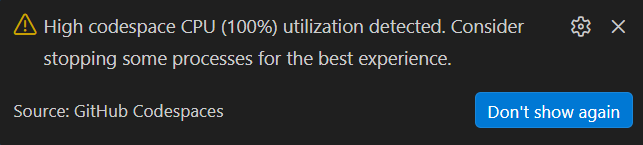

In [ ]:
# ── Preview ───────────────────────────────────────────────────────
stem = pdf_files[0].stem
print(f'=== {TOOL} | {stem} — markdown (first 800 chars) ===')
print(docling_results[stem]['markdown'][:800])
print()
tables = docling_results[stem]['tables']
print(f'Tables found: {len(tables)}')
for tbl in tables[:2]:
    print(f'\n-- Table {tbl["index"]+1} --')
    print(pd.DataFrame(tbl['data'], columns=tbl['cols']).to_string(index=False))

### Tool 2 - Docling evaluation — CER + TEDS

In [ ]:
print(f'=== {TOOL} — CER ===')
for pdf_path in pdf_files:
    stem    = pdf_path.stem
    gt_text = load_gt_text(stem, 2)
    if not gt_text:
        print(f'  {stem}: no ground truth'); continue
    cer_val = compute_cer(docling_results[stem]['plain'], gt_text)
    print(f'  {stem}: CER={cer_val:.4f}  score={cer_to_score5(cer_val)}/5')

In [ ]:
print(f'=== {TOOL} — TEDS ===')
GT_TABLE_STEM = pdf_files[0].stem
GT_TABLE_PAGE = 15
gt_table      = load_gt_table(GT_TABLE_STEM, GT_TABLE_PAGE)

tables_this   = docling_results.get(GT_TABLE_STEM, {}).get('tables', [])
pred_table    = tables_this[0]['data'] if tables_this else []

teds_val = compute_teds(pred_table, gt_table)
print(f'  {GT_TABLE_STEM}: TEDS={teds_val:.4f}  score={teds_to_score5(teds_val)}/5')

res = docling_results[GT_TABLE_STEM]
record(TOOL, GT_TABLE_STEM,
       compute_cer(res['plain'], load_gt_text(GT_TABLE_STEM, 2)),
       teds_val, res['elapsed'], res['pages'],
       notes='Strong table structure + heading hierarchy. Good OCR on scanned docs.')
